In [2]:
!pwd

/home/IITB/vikram-gadre-r-and-d-group/kkt.ai/src


In [3]:
!hostname

rmgpu023


In [4]:
!python --version

Python 3.12.10


GPU availability?

In [5]:
# !python -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"

In [6]:
# from tensorflow.python.client import device_lib
# print(device_lib.list_local_devices())

In [7]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print(f"Details for {gpu.name}:")
        for k, v in details.items():
            print(f"  {k}: {v}")


2025-05-23 00:06:49.609029: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-23 00:06:50.027881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747939010.155438 2858192 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747939010.207732 2858192 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747939010.452072 2858192 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Details for /physical_device:GPU:0:
  compute_capability: (8, 0)
  device_name: NVIDIA A100 80GB PCIe
Details for /physical_device:GPU:1:
  compute_capability: (8, 0)
  device_name: NVIDIA A100 80GB PCIe


In [8]:
# import tensorflow as tf
# print(f"TensorFlow version {tf.__version__}")
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
# gpus = tf.config.list_physical_devices('GPU')
# len(gpus)

Select one GPU

        Restrict code to use a particular GPU...

In [9]:
# # include ../dirx 
mylibpath = [
    '/home/IITB/vikram-gadre-r-and-d-group/kkt.ai/src/utils'
    # '/home/kishoretarafdar/bin'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu

In [10]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [11]:
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [12]:
# select_gpu = gpus[gpu_id]
memory_limit = 8 #GB
select_a_gpu(gpus, gpu_id=1, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

2 Physical GPUs available 
Selected 1 Logical GPU with 8 GB memory limit


I0000 00:00:1747939031.469441 2858192 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8192 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:5e:00.0, compute capability: 8.0


One delay system

In [ ]:
import numpy as np
from scipy.optimize import minimize

# Known input signal
# x = np.array([1,2,3,4,5,6,7])  # shape (L,)
np.random.seed(42)  # Optional: for reproducibility
x = np.random.randint(low=0, high=11, size=1000)  # 100 integers from 0 to 10
x_n1 = np.roll(x, 1)
x_n1[0] = 0

L = len(x)

# Initialize y[n] randomly
np.random.seed(0)
y = np.random.randn(L)
y_n1 = np.roll(y, 1)
y_n1[0] = 0

# Pack variables: y (L values), b0, b1, a1 → total L + 3 variables
def unpack_vars(vars):
    y = vars[:L]
    b0, b1, a1 = vars[L:]
    return y, b0, b1, a1

def loss(vars):
    y, b0, b1, a1 = unpack_vars(vars)
    y_n1 = np.roll(y, 1)
    y_n1[0] = 0
    lhs = b0 * x + b1 * x_n1
    rhs = y + a1 * y_n1
    residual = lhs - rhs
    return np.sum(residual**2)

# Initial guess: random y, reasonable coeffs
y_init = y
params_init = np.array([0.5, 0.5, 0.5])  # b0, b1, a1
vars_init = np.concatenate([y_init, params_init])

# Bounds: b0, b1, a1 > 0; y is unconstrained
bounds = [(None, None)] * L + [(1e-6, None)] * 3

# Optimize
result = minimize(loss, vars_init, bounds=bounds, method='L-BFGS-B')

# Extract results
y_opt, b0_opt, b1_opt, a1_opt = unpack_vars(result.x)

print("Befire y[n]:", y)
print("Optimized b0, b1, a1:", b0_opt, b1_opt, a1_opt)
print("Optimized output y[n]:", y_opt)


Befire y[n]: [ 1.76405235e+00  4.00157208e-01  9.78737984e-01  2.24089320e+00
  1.86755799e+00 -9.77277880e-01  9.50088418e-01 -1.51357208e-01
 -1.03218852e-01  4.10598502e-01  1.44043571e-01  1.45427351e+00
  7.61037725e-01  1.21675016e-01  4.43863233e-01  3.33674327e-01
  1.49407907e+00 -2.05158264e-01  3.13067702e-01 -8.54095739e-01
 -2.55298982e+00  6.53618595e-01  8.64436199e-01 -7.42165020e-01
  2.26975462e+00 -1.45436567e+00  4.57585173e-02 -1.87183850e-01
  1.53277921e+00  1.46935877e+00  1.54947426e-01  3.78162520e-01
 -8.87785748e-01 -1.98079647e+00 -3.47912149e-01  1.56348969e-01
  1.23029068e+00  1.20237985e+00 -3.87326817e-01 -3.02302751e-01
 -1.04855297e+00 -1.42001794e+00 -1.70627019e+00  1.95077540e+00
 -5.09652182e-01 -4.38074302e-01 -1.25279536e+00  7.77490356e-01
 -1.61389785e+00 -2.12740280e-01 -8.95466561e-01  3.86902498e-01
 -5.10805138e-01 -1.18063218e+00 -2.81822283e-02  4.28331871e-01
  6.65172224e-02  3.02471898e-01 -6.34322094e-01 -3.62741166e-01
 -6.72460448

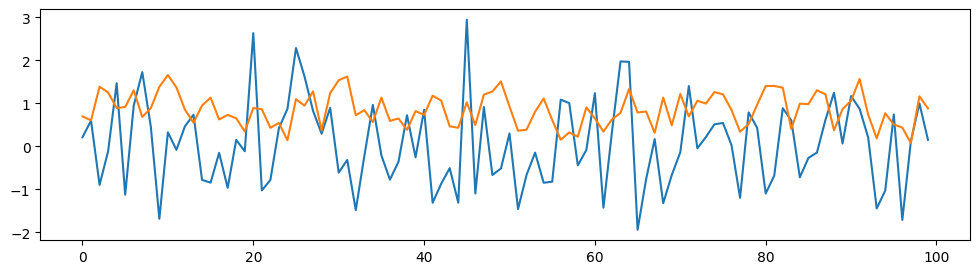

In [ ]:
# plt.figure(figsize=(12,3)), plt.plot(y, '-')
plt.figure(figsize=(12,3)), plt.plot(y_init, '-')

# plt.figure(figsize=(12,3)), 
plt.plot(y_opt, '-')

In [ ]:
# Compute residual error
residual = (b0_opt * x + b1_opt * x_n1) - (y_opt + a1_opt * y_n1)


# Print the residual error statistics
print("Residual error (epsilon[n]):", residual)
print("Max error:", np.max(np.abs(residual)))
print("Mean squared error:", np.mean(residual**2))
np.sum(b0_opt * x + b1_opt * x_n1) - np.sum(y_opt + a1_opt * y_n1)

Residual error (epsilon[n]): [ 4.26912045e-04  6.47216820e-07 -9.71679227e-02 -1.11018537e-02
 -1.29152756e-01 -4.94652325e-02 -2.79094147e-03 -6.50501969e-02
 -1.08209937e-01  3.28547349e-02 -6.92781752e-02 -1.29320463e-01
 -8.96119810e-02 -3.27230676e-02 -8.57491632e-03 -1.93216250e-02
 -9.34777808e-02 -6.68351526e-02  2.42477586e-02 -5.89158895e-02
 -3.71641476e-02  1.70915069e-02 -1.01950761e-01 -3.98403191e-02
  2.95645361e-02 -5.29323532e-02  2.07908571e-02 -1.38153763e-01
 -2.78177714e-02 -7.85565562e-02  5.36863589e-02 -1.50734890e-01
 -1.07341614e-01 -6.19986497e-02  3.87814969e-02 -7.60877872e-02
 -1.69143601e-02 -9.99063574e-02  1.96018640e-02 -3.77132550e-02
 -1.05464305e-02 -7.92696220e-02 -2.59349102e-02 -9.33248235e-02
 -4.32379878e-02  3.43052764e-02 -3.61345916e-02 -1.16013375e-01
  3.88142693e-02 -1.22900439e-01 -7.89960792e-02 -7.80556604e-02
  2.04077612e-03  1.97110153e-02 -4.27612234e-02 -8.15586525e-02
 -6.96788443e-02  2.28584379e-02  2.21730408e-02 -5.18413339e

np.float64(-4.309527173904527)

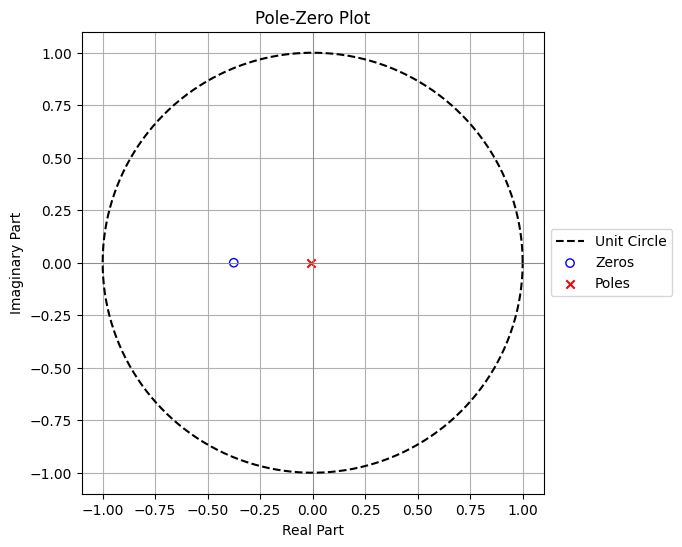

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# Example coefficients (replace these with optimized values)
# From previous result or hypothetical ones
b = np.array([b0_opt, b1_opt])   # feedforward coeffs
a = np.array([1.0, a1_opt])      # feedback coeffs (a0 = 1 by convention)

# Compute roots (zeros and poles)
zeros = np.roots(b)
poles = np.roots(a)

# Unit circle for reference
theta = np.linspace(0, 2*np.pi, 512)
unit_circle = np.exp(1j * theta)

# Plot
plt.figure(figsize=(6,6))
plt.plot(np.real(unit_circle), np.imag(unit_circle), 'k--', label='Unit Circle')
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', facecolors='none', edgecolors='b', label='Zeros')
plt.scatter(np.real(poles), np.imag(poles), marker='x', color='r', label='Poles')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.gca().set_aspect('equal')
plt.title('Pole-Zero Plot')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
# plt.legend()
# Legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()


# two delay system

In [ ]:
import numpy as np
from scipy.optimize import minimize

# Generate random input signal
np.random.seed(42)
x = np.random.randint(0, 11, size=10000)

L = len(x)

# Initialize output signal y[n]
y_init = np.random.randn(L)

# Prepare x[n-1] and x[n-2]
x_n1 = np.roll(x, 1)
x_n2 = np.roll(x, 2)
x_n1[0] = 0
x_n2[:2] = 0

# Define how to unpack variables
def unpack_vars(vars):
    y = vars[:L]
    b0, b1, b2, a1, a2 = vars[L:]
    return y, b0, b1, b2, a1, a2

# Define the loss function
def loss(vars):
    y, b0, b1, b2, a1, a2 = unpack_vars(vars)
    y_n1 = np.roll(y, 1)
    y_n2 = np.roll(y, 2)
    y_n1[0] = 0
    y_n2[:2] = 0

    lhs = b0 * x + b1 * x_n1 + b2 * x_n2
    rhs = y + a1 * y_n1 + a2 * y_n2
    residual = lhs - rhs
    return np.sum(residual ** 2)

# Initial guesses
params_init = np.array([0.5, 0.5, 0.5, 0.5, 0.5])  # b0, b1, b2, a1, a2
vars_init = np.concatenate([y_init, params_init])

# Bounds: y is unconstrained; all coeffs > 0
bounds = [(None, None)] * L + [(1e-6, None)] * 5

# Run optimization
result = minimize(loss, vars_init, bounds=bounds, method='L-BFGS-B')

# Extract optimized values
y_opt, b0_opt, b1_opt, b2_opt, a1_opt, a2_opt = unpack_vars(result.x)

# Print results
print("Optimized coefficients:")
print("b0 =", b0_opt, ", b1 =", b1_opt, ", b2 =", b2_opt)
print("a1 =", a1_opt, ", a2 =", a2_opt)

# Check residual error
y_n1 = np.roll(y_opt, 1)
y_n2 = np.roll(y_opt, 2)
y_n1[0] = 0
y_n2[:2] = 0

residual = (b0_opt * x + b1_opt * x_n1 + b2_opt * x_n2) - (y_opt + a1_opt * y_n1 + a2_opt * y_n2)

print("Max residual error:", np.max(np.abs(residual)))
print("Mean squared error:", np.mean(residual**2))


Optimized coefficients:
b0 = 0.48653887815308927 , b1 = 0.48653887815308927 , b2 = 0.48653887815308927
a1 = 0.48653887815308927 , a2 = 0.48653887815308927
Max residual error: 13.931997766460082
Mean squared error: 38.6485372434605


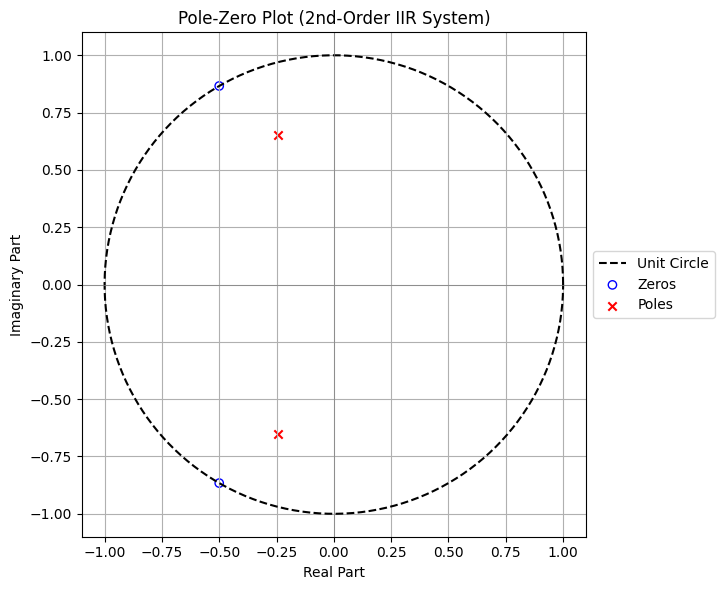

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use your optimized coefficients from previous step
b = np.array([b0_opt, b1_opt, b2_opt])
a = np.array([1.0, a1_opt, a2_opt])  # a0 is always 1

# Compute poles and zeros
zeros = np.roots(b)
poles = np.roots(a)

# Unit circle
theta = np.linspace(0, 2 * np.pi, 512)
unit_circle = np.exp(1j * theta)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(np.real(unit_circle), np.imag(unit_circle), 'k--', label='Unit Circle')
plt.scatter(np.real(zeros), np.imag(zeros), facecolors='none', edgecolors='b', marker='o', label='Zeros')
plt.scatter(np.real(poles), np.imag(poles), color='r', marker='x', label='Poles')

# Axis formatting
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.gca().set_aspect('equal')
plt.title('Pole-Zero Plot (2nd-Order IIR System)')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.grid(True)

# Legend outside plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


D delay iir system

In [ ]:
import numpy as np
from scipy.optimize import minimize

def create_delays(signal, D):
    """Returns matrix where each column is signal delayed by k (0 to D)."""
    L = len(signal)
    delayed = np.zeros((L, D + 1))
    for k in range(D + 1):
        delayed[:, k] = np.roll(signal, k)
        delayed[:k, k] = 0  # zero-padding for initial values
    return delayed

def iir_loss(vars, x, L, D):
    y = vars[:L]
    b_coeffs = vars[L:L + D + 1]      # b0 to bD
    a_coeffs = vars[L + D + 1:]       # a1 to aD

    x_delayed = create_delays(x, D)           # x[n], x[n-1], ..., x[n-D]
    y_delayed = create_delays(y, D)[:, 1:]     # y[n-1] to y[n-D]

    lhs = x_delayed @ b_coeffs
    rhs = y + y_delayed @ a_coeffs
    residual = lhs - rhs

    return np.sum(residual ** 2)

def optimize_iir(x, D):
    L = len(x)
    y_init = np.random.randn(L)
    b_init = np.full(D + 1, 0.5)
    a_init = np.full(D, 0.5)

    vars_init = np.concatenate([y_init, b_init, a_init])
    bounds = [(None, None)] * L + [(1e-6, None)] * (D + 1 + D)

    result = minimize(iir_loss, vars_init, args=(x, L, D), bounds=bounds, method='L-BFGS-B')

    y_opt = result.x[:L]
    b_opt = result.x[L:L + D + 1]
    a_opt = result.x[L + D + 1:]
    return y_opt, b_opt, a_opt, result


In [ ]:
np.random.seed(42)
x = np.random.randint(0, 11, size=1000)

D = 10  # system delay order

y_opt, b_opt, a_opt, result = optimize_iir(x, D)

print("Optimized b:", b_opt)
print("Optimized a:", a_opt)

# Compute final residual
x_delayed = create_delays(x, D)
y_delayed = create_delays(y_opt, D)[:, 1:]
residual = (x_delayed @ b_opt) - (y_opt + y_delayed @ a_opt)

print("Max residual:", np.max(np.abs(residual)))
print("Mean squared residual:", np.mean(residual**2))


Optimized b: [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06]
Optimized a: [4.48709811e-02 3.52953459e-02 2.06329029e-02 3.43490613e-02
 2.67855239e-02 2.96152104e-02 1.00000000e-06 3.47557102e-02
 1.00000000e-06 1.00000000e-06]
Max residual: 3.136961502953925
Mean squared residual: 0.9584645350132555


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pole_zero(b, a):
    """
    Plots the pole-zero diagram given numerator b and denominator a coefficients.
    Assumes: a0 = 1 is already included.
    """
    zeros = np.roots(b)
    poles = np.roots(a)

    # Unit circle
    theta = np.linspace(0, 2 * np.pi, 512)
    unit_circle = np.exp(1j * theta)

    plt.figure(figsize=(7, 6))
    plt.plot(np.real(unit_circle), np.imag(unit_circle), 'k--', label='Unit Circle')
    plt.scatter(np.real(zeros), np.imag(zeros), facecolors='none', edgecolors='b', marker='o', label='Zeros')
    plt.scatter(np.real(poles), np.imag(poles), color='r', marker='x', label='Poles')

    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.gca().set_aspect('equal')
    plt.title('Pole-Zero Plot (General D-Delay IIR System)')
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.grid(True)

    # Legend outside plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()


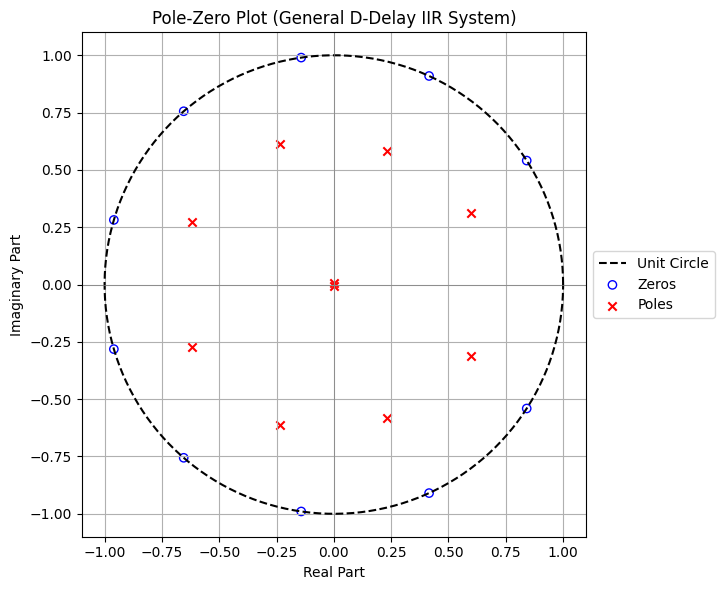

In [ ]:
# From previous optimization
# b_opt = [b0, b1, ..., bD]
# a_opt = [a1, a2, ..., aD]

a_full = np.concatenate([[1.0], a_opt])  # a0 = 1
plot_pole_zero(b_opt, a_full)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

def plot_frequency_response(b, a, fs=1.0):
    """
    Plots the magnitude and phase response of the IIR filter defined by b and a.
    fs = sampling frequency (set to 1.0 if unknown).
    """
    w, h = freqz(b, a, worN=1024, fs=fs)  # w in Hz if fs is provided

    # Magnitude (in dB) and Phase (in radians)
    plt.figure(figsize=(10, 6))

    # Magnitude plot
    plt.subplot(2, 1, 1)
    plt.plot(w, 20 * np.log10(abs(h)), 'b')
    plt.title('Frequency Response')
    plt.ylabel('Magnitude (dB)')
    plt.grid(True)

    # Phase plot
    plt.subplot(2, 1, 2)
    plt.plot(w, np.angle(h), 'r')
    plt.ylabel('Phase (radians)')
    plt.xlabel('Frequency (Hz)' if fs != 1.0 else 'Normalized Frequency (×π rad/sample)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


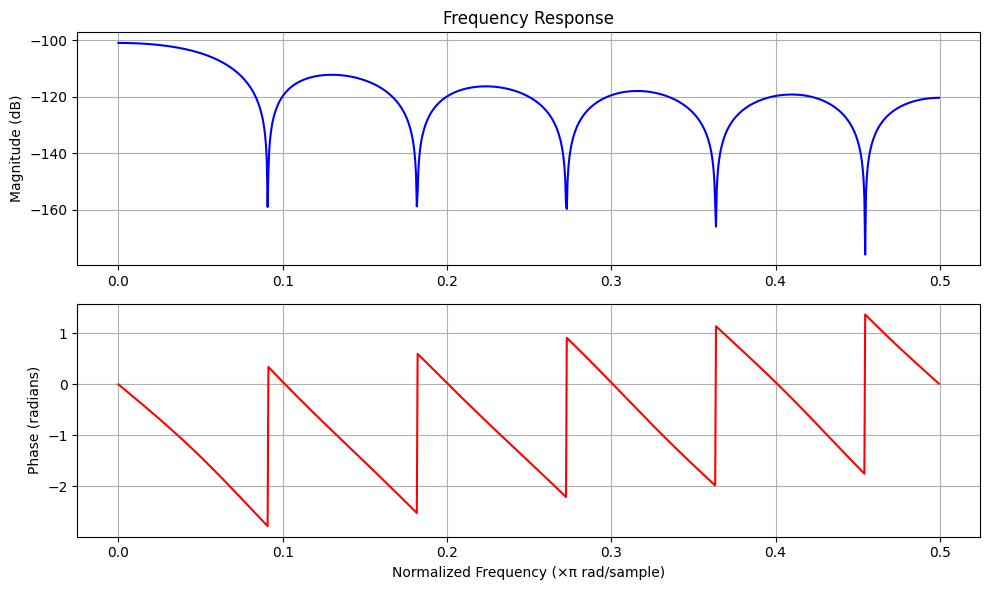

In [ ]:
# Assuming b_opt and a_opt from optimization
a_full = np.concatenate([[1.0], a_opt])  # include a0 = 1

# If you're not working with real time signals, keep fs=1.0
plot_frequency_response(b_opt, a_full)


In [ ]:
import tensorflow as tf

class OptimizingIIRLayer(tf.keras.layers.Layer):
    def __init__(self, D, **kwargs):
        super(OptimizingIIRLayer, self).__init__(**kwargs)
        self.D = D  # Delay order

    def build(self, input_shape):
        _, N, C = input_shape

        # Initialize feedforward coefficients: (D+1, C)
        self.b = self.add_weight(
            shape=(self.D + 1, C),
            initializer=tf.keras.initializers.Constant(0.5),
            trainable=True,
            constraint=tf.keras.constraints.NonNeg(),
            name="b_coeffs"
        )

        # Initialize feedback coefficients: (D, C)
        self.a = self.add_weight(
            shape=(self.D, C),
            initializer=tf.keras.initializers.Constant(0.5),
            trainable=True,
            constraint=tf.keras.constraints.NonNeg(),
            name="a_coeffs"
        )

        # Initialize output signal y: (1, N, C) — broadcastable
        self.y_init = self.add_weight(
            shape=(1, N, C),
            initializer="random_normal",
            trainable=True,
            name="y_signal"
        )

    def create_delays_tf(self, signal, D):
        """Create delayed versions of signal: (B, N, C) -> (B, N, D+1, C)"""
        batch_size = tf.shape(signal)[0]
        N = tf.shape(signal)[1]
        C = tf.shape(signal)[2]

        delayed = []

        for k in range(D + 1):
            shifted = tf.roll(signal, shift=k, axis=1)
            if k > 0:
                pad = tf.zeros((batch_size, k, C), dtype=signal.dtype)
                shifted = tf.concat([pad, shifted[:, k:, :]], axis=1)
            delayed.append(shifted)

        return tf.stack(delayed, axis=2)  # shape (B, N, D+1, C)

    def call(self, x):
        B = tf.shape(x)[0]

        # Repeat y_init for batch
        y = tf.tile(self.y_init, [B, 1, 1])  # (B, N, C)

        # Compute delayed x and y
        x_delayed = self.create_delays_tf(x, self.D)  # (B, N, D+1, C)
        y_delayed = self.create_delays_tf(y, self.D)[:, :, 1:, :]  # (B, N, D, C)

        # Compute left-hand side: x convolutions
        lhs = tf.reduce_sum(x_delayed * tf.reshape(self.b, (1, 1, self.D + 1, -1)), axis=2)

        # Compute right-hand side: y[n] + feedback
        rhs = y + tf.reduce_sum(y_delayed * tf.reshape(self.a, (1, 1, self.D, -1)), axis=2)

        # Residual: should be nearly zero
        residual = lhs - rhs

        self.add_loss(tf.reduce_mean(residual ** 2))

        return y  # (B, N, C) optimized output

# Example usage:
layer = OptimizingIIRLayer(D=2)
dummy_input = tf.random.normal((2, 100, 20))  # (batch_size, N, channels)
output = layer(dummy_input)
print("Output shape:", output.shape)


Output shape: (2, 100, 20)


In [ ]:
import tensorflow as tf
import numpy as np
from scipy.optimize import minimize

class OptimizingIIRLayer(tf.keras.layers.Layer):
    def __init__(self, D, **kwargs):
        super(OptimizingIIRLayer, self).__init__(**kwargs)
        self.D = D

    def build(self, input_shape):
        _, N, C = input_shape
        self.N = N
        self.C = C

    def create_delays_np(self, signal, D):
        L = signal.shape[0]
        delayed = np.zeros((L, D + 1))
        for k in range(D + 1):
            delayed[k:, k] = signal[:L - k]
        return delayed

    def iir_loss(self, vars, x, L, D):
        y = vars[:L]
        b = vars[L:L + D + 1]
        a = vars[L + D + 1:]

        x_delayed = self.create_delays_np(x, D)
        y_delayed = self.create_delays_np(y, D)[:, 1:]

        lhs = x_delayed @ b
        rhs = y + y_delayed @ a
        residual = lhs - rhs

        return np.sum(residual ** 2)

    def optimize_single_channel(self, x_channel):
        L = x_channel.shape[0]
        y_init = np.random.randn(L)
        b_init = np.full(self.D + 1, 0.5)
        a_init = np.full(self.D, 0.5)
        vars_init = np.concatenate([y_init, b_init, a_init])
        bounds = [(None, None)] * L + [(1e-6, None)] * (self.D + 1 + self.D)

        result = minimize(self.iir_loss, vars_init, args=(x_channel, L, self.D), bounds=bounds, method='L-BFGS-B')

        y_opt = result.x[:L]
        b_opt = result.x[L:L + self.D + 1]
        a_opt = result.x[L + self.D + 1:]
        return y_opt, b_opt, a_opt

    def call(self, x):
        x_np = x.numpy()
        B, L, C = x_np.shape
        y_out = np.zeros((B, L, C))

        for b in range(B):
            for c in range(C):
                x_bc = x_np[b, :, c]
                y_opt, _, _ = self.optimize_single_channel(x_bc)
                y_out[b, :, c] = y_opt

        return tf.convert_to_tensor(y_out, dtype=tf.float32)

# Example usage:
layer = OptimizingIIRLayer(D=2)
dummy_input = tf.random.normal((2, 100, 10))
output = layer(dummy_input)
print("Output shape:", output.shape)


Output shape: (2, 100, 10)


Input Shape: (2, 1000, 3)
Output Shape: (2, 1000, 3)
Shape of b coefficients: (2, 11, 3)
Shape of a coefficients: (2, 10, 3)


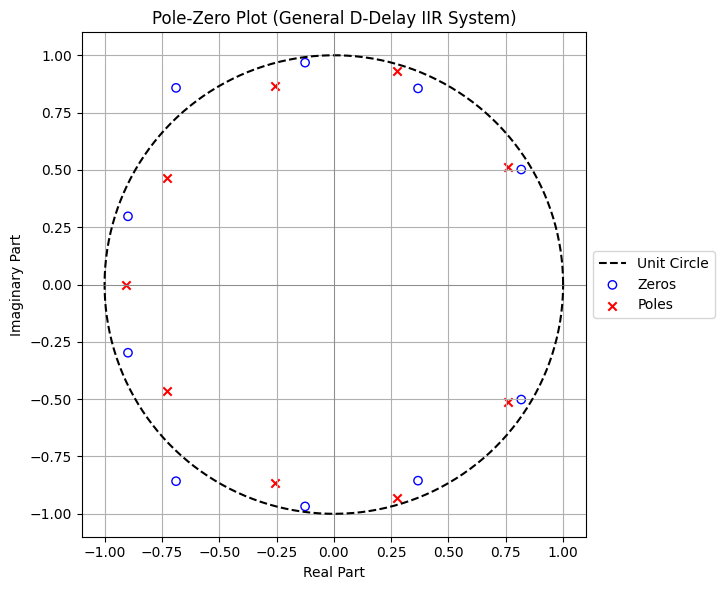

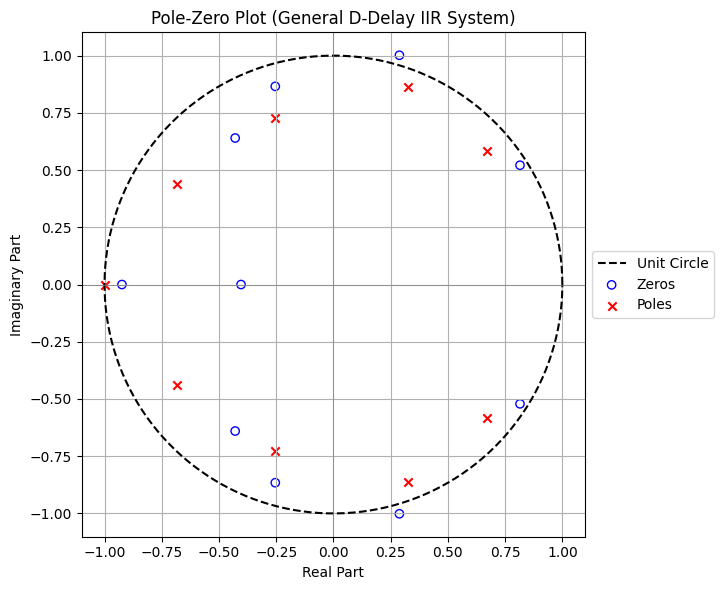

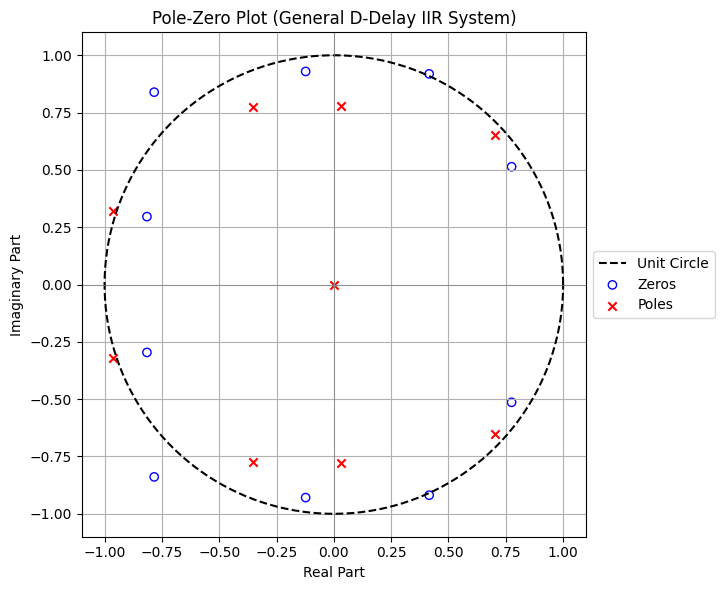

In [ ]:
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial as P

# Updated class to return a and b coeffs for plotting
class OptimizingIIRLayer(tf.keras.layers.Layer):
    def __init__(self, D, **kwargs):
        super(OptimizingIIRLayer, self).__init__(**kwargs)
        self.D = D

    def build(self, input_shape):
        _, N, C = input_shape
        self.N = N
        self.C = C

    def create_delays_np(self, signal, D):
        L = signal.shape[0]
        delayed = np.zeros((L, D + 1))
        for k in range(D + 1):
            delayed[k:, k] = signal[:L - k]
        return delayed

    def iir_loss(self, vars, x, L, D):
        y = vars[:L]
        b = vars[L:L + D + 1]
        a = vars[L + D + 1:]

        x_delayed = self.create_delays_np(x, D)
        y_delayed = self.create_delays_np(y, D)[:, 1:]

        lhs = x_delayed @ b
        rhs = y + y_delayed @ a
        residual = lhs - rhs

        return np.sum(residual ** 2)

    def optimize_single_channel(self, x_channel):
        L = x_channel.shape[0]
        y_init = np.random.randn(L)
        b_init = np.full(self.D + 1, 0.5)
        a_init = np.full(self.D, 0.5)
        vars_init = np.concatenate([y_init, b_init, a_init])
        bounds = [(None, None)] * L + [(1e-6, None)] * (self.D + 1 + self.D)

        result = minimize(self.iir_loss, vars_init, args=(x_channel, L, self.D), bounds=bounds, method='L-BFGS-B')

        y_opt = result.x[:L]
        b_opt = result.x[L:L + self.D + 1]
        a_opt = result.x[L + self.D + 1:]
        return y_opt, b_opt, a_opt

    def call(self, x):
        x_np = x.numpy()
        B, L, C = x_np.shape
        y_out = np.zeros((B, L, C))
        all_b = np.zeros((B, self.D + 1, C))
        all_a = np.zeros((B, self.D, C))

        for b in range(B):
            for c in range(C):
                x_bc = x_np[b, :, c]
                y_opt, b_opt, a_opt = self.optimize_single_channel(x_bc)
                y_out[b, :, c] = y_opt
                all_b[b, :, c] = b_opt
                all_a[b, :, c] = a_opt

        # Save for later use (e.g., plotting)
        self.last_a = all_a
        self.last_b = all_b
        return tf.convert_to_tensor(y_out, dtype=tf.float32)

# Instantiate and run
layer = OptimizingIIRLayer(D=10)
dummy_input = tf.random.normal((2, 1000, 3))
output = layer(dummy_input)
print("Input Shape:", dummy_input.shape)  # (batch, D+1, channels)
print("Output Shape:", output.shape)  # (batch, D, channels)
# Print shapes of a and b
print("Shape of b coefficients:", layer.last_b.shape)  # (batch, D+1, channels)
print("Shape of a coefficients:", layer.last_a.shape)  # (batch, D, channels)

# # Plot pole-zero for one example
# def plot_pole_zero(b, a):
#     # a: [a1, ..., aD] → we prepend 1
#     a_full = np.concatenate([[1.0], a])
#     z = np.roots(b)
#     p = np.roots(a_full)

#     plt.figure(figsize=(10, 10))
#     plt.scatter(np.real(z), np.imag(z), c='blue', marker='o', label='Zeros')
#     plt.scatter(np.real(p), np.imag(p), c='red', marker='x', label='Poles')
#     plt.axhline(0, color='gray')
#     plt.axvline(0, color='gray')
#     unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
#     plt.gca().add_artist(unit_circle)
#     plt.gca().set_aspect('equal')
#     plt.title("Pole-Zero Plot")
#     plt.legend(loc='upper left')
#     plt.grid(True)
#     plt.show()

# Plot for first batch and first channel
b_example = layer.last_b[0, :, 0]
a_example = layer.last_a[0, :, 0]
plot_pole_zero(b_example, a_example)


b_example = layer.last_b[1, :, 0]
a_example = layer.last_a[1, :, 0]
plot_pole_zero(b_example, a_example)



b_example = layer.last_b[1, :, 1]
a_example = layer.last_a[1, :, 1]
plot_pole_zero(b_example, a_example)

# 1D IIR layer

Input Shape: (2, 1000, 10)
Output Shape: (2, 1000, 10)
Shape of b coefficients: (2, 11, 10)
Shape of a coefficients: (2, 10, 10)


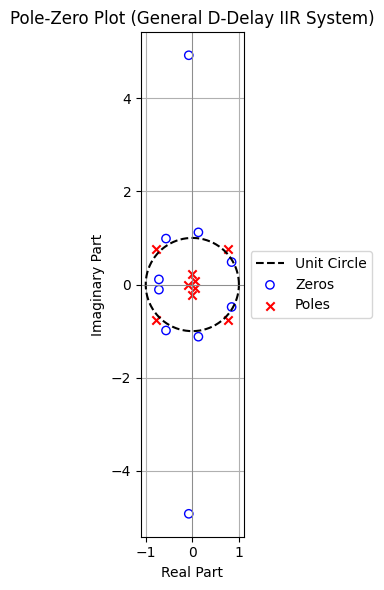

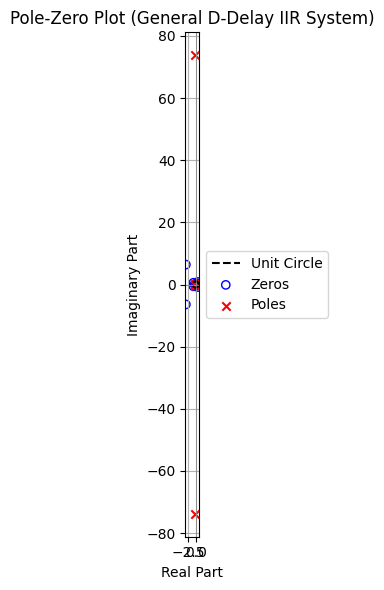

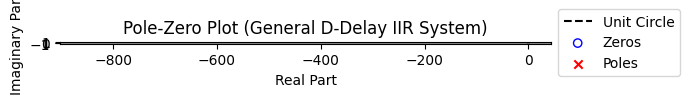

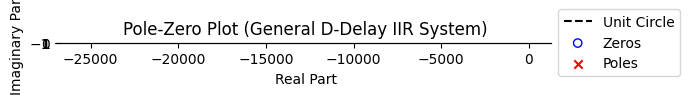

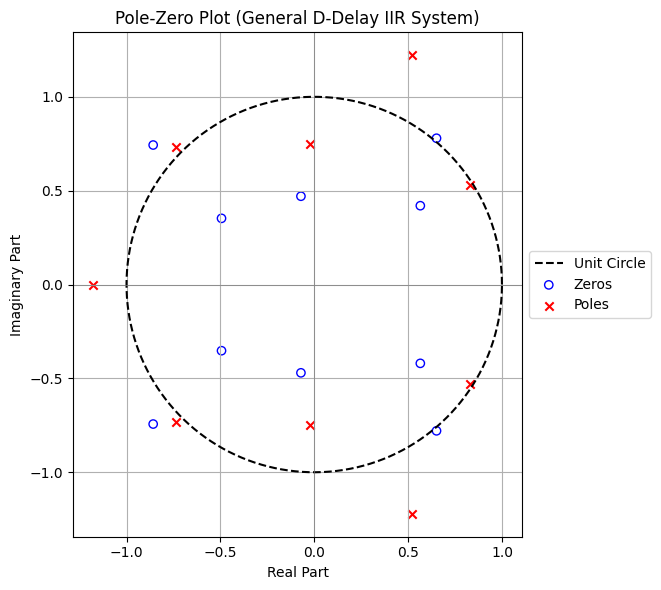

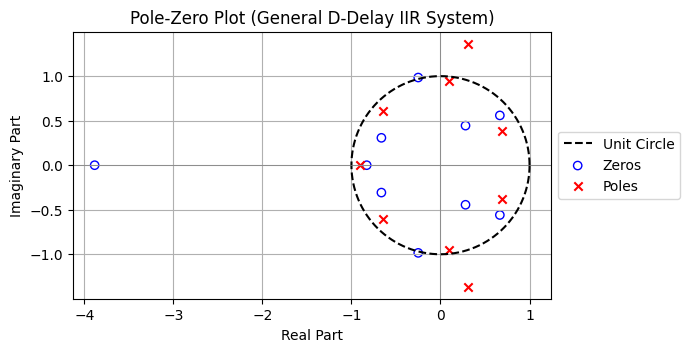

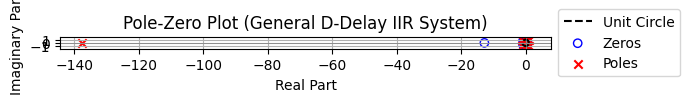

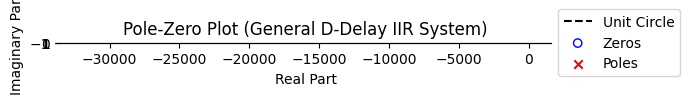

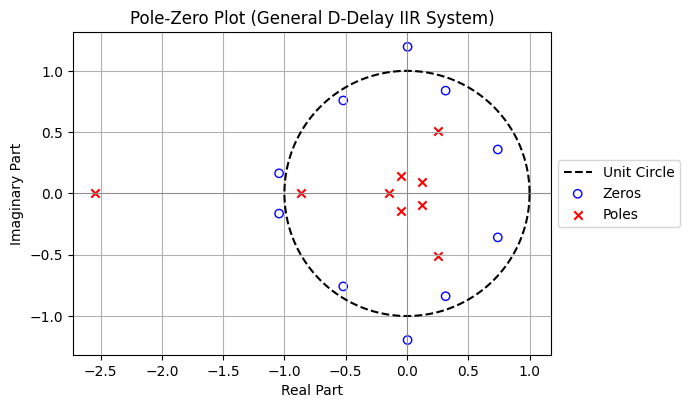

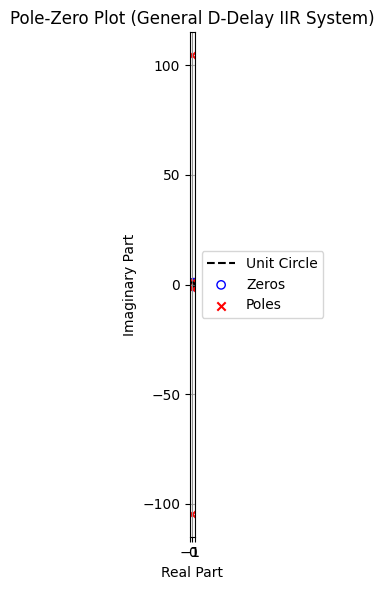

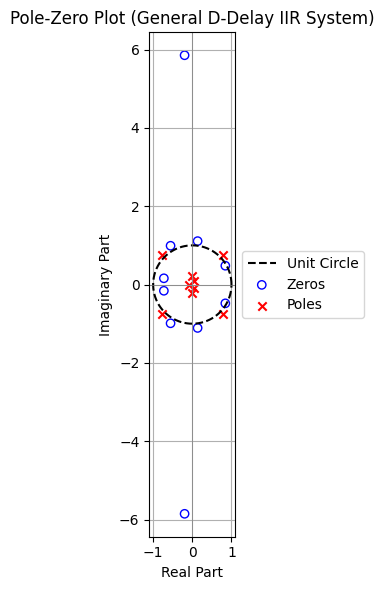

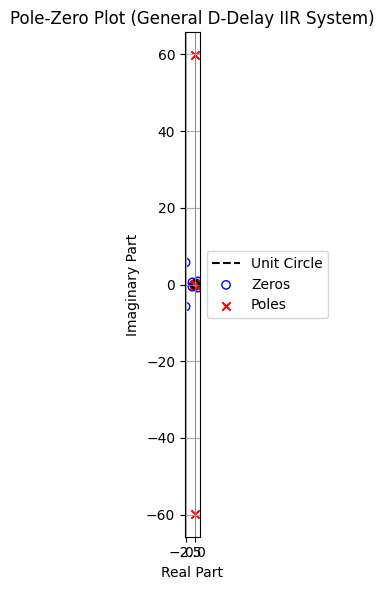

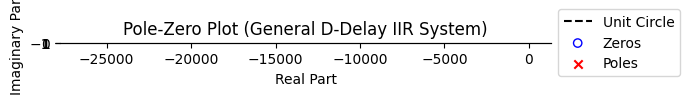

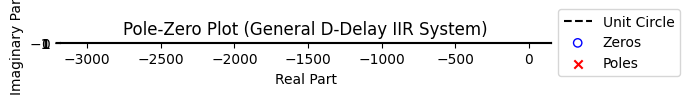

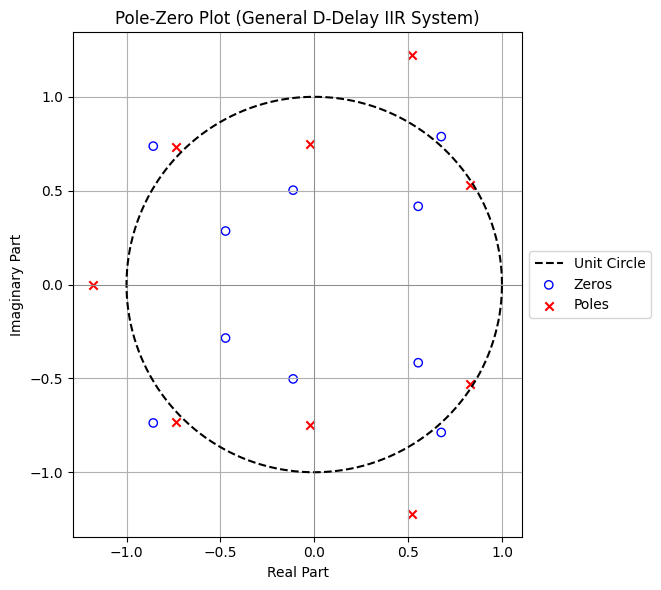

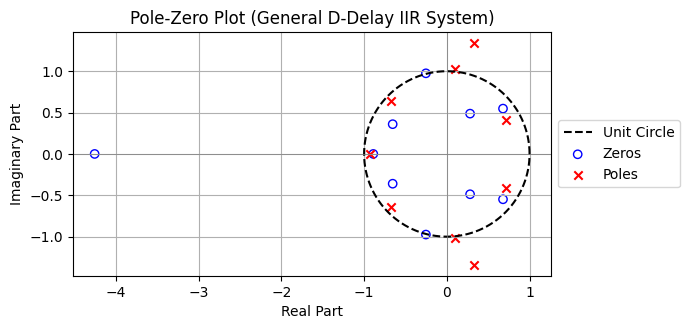

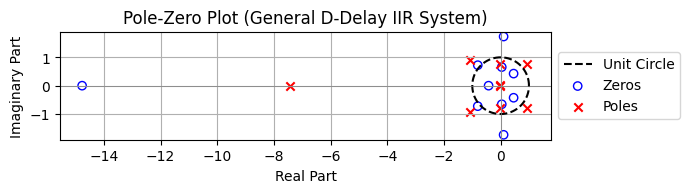

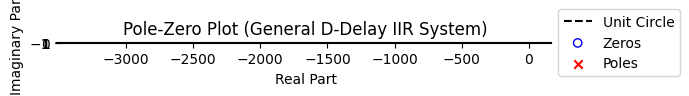

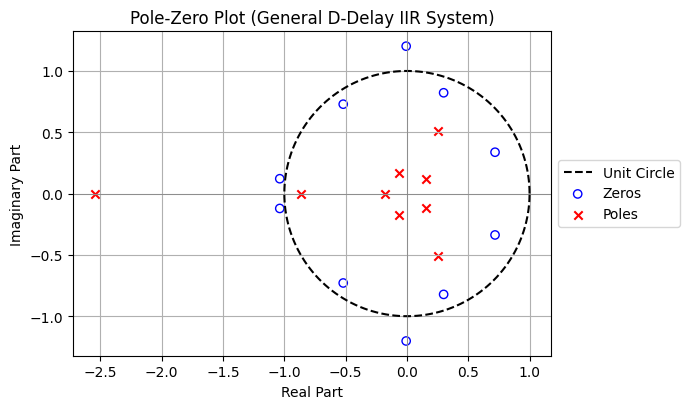

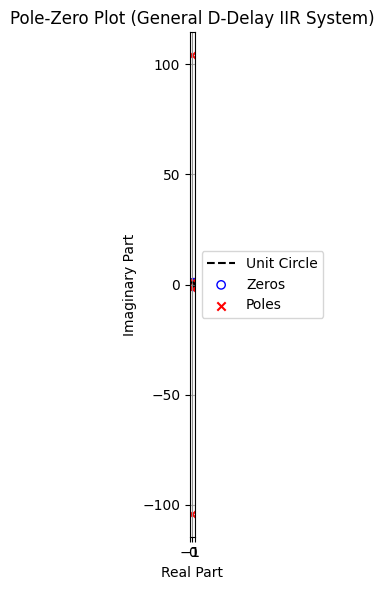

In [102]:
import tensorflow as tf
import numpy as np
from scipy.optimize import minimize

class HybridIIRLayer(tf.keras.layers.Layer):
    def __init__(self, D, **kwargs):
        super(HybridIIRLayer, self).__init__(**kwargs)
        self.D = D  # Number of delays

    def build(self, input_shape):
        _, N, C = input_shape  # Batch, Time, Channels
        self.N = N
        self.C = C

        # Trainable feedback and feedforward coefficients
        self.a = self.add_weight(
            shape=(self.C, self.D), initializer="random_normal", trainable=True, name="a_coeffs"
        )
        self.b = self.add_weight(
            shape=(self.C, self.D + 1), initializer="random_normal", trainable=True, name="b_coeffs"
        )

        # Trainable initial output
        self.y_init = self.add_weight(
            shape=(1, self.N, self.C), initializer="zeros", trainable=True, name="y_init"
        )

    def create_delays_np(self, signal, D):
        L = signal.shape[0]
        delayed = np.zeros((L, D + 1))
        for k in range(D + 1):
            delayed[k:, k] = signal[:L - k]
        return delayed

        

    def iir_loss(self, vars, x, L, D):
        y = vars[:L]
        b = vars[L:L + D + 1]
        a = vars[L + D + 1:]

        x_delayed = self.create_delays_np(x, D)
        y_delayed = self.create_delays_np(y, D)[:, 1:]

        lhs = x_delayed @ b
        rhs = y + y_delayed @ a
        residual = lhs - rhs

        return np.sum(residual ** 2)

    def optimize_single_channel(self, x_channel, y_init, b_init, a_init):
        L = x_channel.shape[0]
        vars_init = np.concatenate([y_init, b_init, a_init])
        bounds = [(None, None)] * L + [(1e-6, None)] * (self.D + 1 + self.D)

        result = minimize(self.iir_loss, vars_init, args=(x_channel, L, self.D), bounds=bounds, method='L-BFGS-B')

        y_opt = result.x[:L]
        b_opt = result.x[L:L + self.D + 1]
        a_opt = result.x[L + self.D + 1:]
        return y_opt, b_opt, a_opt

    def call(self, x):
        x_np = x.numpy()
        B, L, C = x_np.shape
        y_out = np.zeros((B, L, C))
        all_b = np.zeros((B, self.D + 1, C))
        all_a = np.zeros((B, self.D, C))

        for b in range(B):
            for c in range(C):
                x_bc = x_np[b, :, c]
                y_init_np = self.y_init[0, :, c].numpy()
                b_init_np = self.b[c].numpy()
                a_init_np = self.a[c].numpy()
                y_opt, b_opt, a_opt = self.optimize_single_channel(x_bc, y_init_np, b_init_np, a_init_np)
                y_out[b, :, c] = y_opt
                all_b[b, :, c] = b_opt
                all_a[b, :, c] = a_opt

        self.last_b = all_b
        self.last_a = all_a
        return tf.convert_to_tensor(y_out, dtype=tf.float32)


# Instantiate and run
layer = HybridIIRLayer(D=10)
bs, Ns, cs = 2, 1000, 10 #batchsize, Ns, cs#
dummy_input = tf.random.normal((bs, Ns, cs))
output = layer(dummy_input)
print("Input Shape:", dummy_input.shape)  # (batch, D+1, channels)
print("Output Shape:", output.shape)  # (batch, D, channels)
# Print shapes of a and b
print("Shape of b coefficients:", layer.last_b.shape)  # (batch, D+1, channels)
print("Shape of a coefficients:", layer.last_a.shape)  # (batch, D, channels)

for j in range(bs):
    for i in range(cs):
        # Plot for first batch and first channel
        b_example = layer.last_b[j, :, i]
        a_example = layer.last_a[j, :, i]
        plot_pole_zero(b_example, a_example)




In [105]:
import tensorflow as tf

class HybridIIRLayer(tf.keras.layers.Layer):
    def __init__(self, D, **kwargs):
        super(HybridIIRLayer, self).__init__(**kwargs)
        self.D = D  # Number of delays

    def build(self, input_shape):
        # input_shape = (batch, time, channels)
        B, N, C = input_shape
        self.N = N
        self.C = C

        # Trainable feedforward (b) and feedback (a) coeffs
        self.a = self.add_weight(
            shape=(self.C, self.D), initializer="random_normal", trainable=True, name="a_coeffs"
        )
        self.b = self.add_weight(
            shape=(self.C, self.D + 1), initializer="random_normal", trainable=True, name="b_coeffs"
        )

        # Precompute delay indices for input x: shape [N, D+1]
        n = tf.range(self.N)
        self.row_indices = tf.math.mod(
            tf.expand_dims(n, axis=1) - tf.expand_dims(tf.range(self.D + 1), axis=0), self.N
        )  # shape [N, D+1]

    def call(self, x):
        """
        x: [B, N, C]
        Returns y: [B, N, C] filtered output
        Implements IIR filtering y[n] = sum_i b_i * x[n-i] - sum_j a_j * y[n-j]
        """
        B = tf.shape(x)[0]
        N = tf.shape(x)[1]
        C = tf.shape(x)[2]

        # Reshape x to [B*C, N] to use gather with indices on axis=1
        x_flat = tf.reshape(tf.transpose(x, [0, 2, 1]), [B * C, N])  # [B*C, N]

        # Gather delayed inputs for feedforward part: [B*C, N, D+1]
        x_delayed = tf.gather(x_flat, self.row_indices, axis=1, batch_dims=1)  # delayed inputs

        # Reshape back: [B, C, N, D+1]
        x_delayed = tf.reshape(x_delayed, [B, C, N, self.D + 1])
        # Transpose to [B, N, C, D+1]
        x_delayed = tf.transpose(x_delayed, [0, 2, 1, 3])

        # Expand b: [1, 1, C, D+1]
        b = tf.reshape(self.b, [1, 1, C, self.D + 1])

        # Compute feedforward contribution: sum over D+1 delays for each channel
        y_ff = tf.reduce_sum(x_delayed * b, axis=-1)  # [B, N, C]

        # Initialize output y with zeros [B, N, C]
        y = tf.TensorArray(dtype=tf.float32, size=N)
        # First output = feedforward at time 0 (no feedback yet)
        y = y.write(0, y_ff[:, 0, :])

        # For feedback, we'll keep track of previous outputs
        for n in tf.range(1, N):
            # Stack previous outputs up to delay D (or less if n < D)
            max_delay = tf.minimum(n, self.D)
            y_prev = y.stack()  # [n, B, C]
            y_prev = tf.transpose(y_prev, [1, 0, 2])  # [B, n, C]

            # Collect delayed outputs for feedback: shape [B, D, C], zero-pad if needed
            y_delays = []
            for k in range(self.D):
                idx = n - k - 1
                val = tf.where(idx >= 0, y_prev[:, idx, :], tf.zeros_like(y_ff[:, 0, :]))
                y_delays.append(val)
            y_delays = tf.stack(y_delays, axis=1)  # [B, D, C]

            # a coeffs: [C, D] -> reshape to [1, D, C]
            a = tf.reshape(self.a, [1, self.D, C])

            # Compute feedback: sum over delays weighted by a
            y_fb = tf.reduce_sum(y_delays * a, axis=1)  # [B, C]

            # Calculate current output y[n]
            y_next = y_ff[:, n, :] - y_fb  # [B, C]
            y = y.write(n, y_next)

        # Stack y outputs: [N, B, C] -> transpose to [B, N, C]
        y = y.stack()
        y = tf.transpose(y, [1, 0, 2])

        return y

    def compute_output_shape(self, input_shape):
        return input_shape



# Instantiate and run
layer = HybridIIRLayer(D=10)
bs, Ns, cs = 2, 1000, 10 #batchsize, Ns, cs#
dummy_input = tf.random.normal((bs, Ns, cs))
output = layer(dummy_input)
print("Input Shape:", dummy_input.shape)  # (batch, D+1, channels)
print("Output Shape:", output.shape)  # (batch, D, channels)
# Print shapes of a and b
print("Shape of b coefficients:", layer.b.shape)  # (batch, D+1, channels)
print("Shape of a coefficients:", layer.a.shape)  # (batch, D, channels)

for j in range(bs):
    for i in range(cs):
        # Plot for first batch and first channel
        b_example = layer.b[j, :, i]
        a_example = layer.a[j, :, i]
        plot_pole_zero(b_example, a_example)



2025-05-23 03:03:45.778061: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: params.shape[0]: 20 should be equal to indices.shape[0]: 1000


InvalidArgumentError: Exception encountered when calling HybridIIRLayer.call().

[1m{{function_node __wrapped__GatherV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} params.shape[0]: 20 should be equal to indices.shape[0]: 1000 [Op:GatherV2] name: [0m

Arguments received by HybridIIRLayer.call():
  • x=tf.Tensor(shape=(2, 1000, 10), dtype=float32)

In [ ]:
import tensorflow as tf
from scipy.optimize import minimize

class HybridIIRLayer(tf.keras.layers.Layer):
    def __init__(self, D, **kwargs):
        super(HybridIIRLayer, self).__init__(**kwargs)
        self.D = D  # Number of delays

    def build(self, input_shape):
        _, self.N, self.C = input_shape  # Batch, Time, Channels

        # Trainable feedback and feedforward coefficients
        self.a = self.add_weight(
            shape=(self.C, self.D), initializer="random_normal", trainable=True, name="a_coeffs"
        )
        self.b = self.add_weight(
            shape=(self.C, self.D + 1), initializer="random_normal", trainable=True, name="b_coeffs"
        )

        # Trainable initial output (used only for initialization in optimization)
        self.y_init = self.add_weight(
            shape=(1, self.N, self.C), initializer="zeros", trainable=True, name="y_init"
        )

        # Create row indices for delay generation (used in TF delay logic)
        n = tf.range(self.N)
        self.row_indices = tf.maximum(0, n[:, tf.newaxis] - tf.range(self.D + 1))  # [N, D+1]

    def create_delays_tf(self, signal):
        # signal: [B, N] -> [B, N, D+1]
        # row_indices: [N, D+1], gather from time axis
        return tf.gather(signal, self.row_indices, axis=1, batch_dims=0)  # [B, N, D+1]

    def iir_loss(self, vars, x, L, D):
        y = vars[:L]
        b = vars[L:L + D + 1]
        a = vars[L + D + 1:]

        # Delays for optimization (NumPy version because of `scipy.optimize`)
        def create_delays_np(signal, D):
            L = signal.shape[0]
            delayed = np.zeros((L, D + 1))
            for k in range(D + 1):
                delayed[k:, k] = signal[:L - k]
            return delayed

        x_delayed = create_delays_np(x, D)
        y_delayed = create_delays_np(y, D)[:, 1:]

        lhs = x_delayed @ b
        rhs = y + y_delayed @ a
        residual = lhs - rhs

        return np.sum(residual ** 2)

    def optimize_single_channel(self, x_channel, y_init, b_init, a_init):
        L = x_channel.shape[0]
        vars_init = tf.concat([y_init, b_init, a_init], axis=0).numpy()
        bounds = [(None, None)] * L + [(1e-6, None)] * (self.D + 1 + self.D)

        result = minimize(self.iir_loss, vars_init, args=(x_channel, L, self.D), bounds=bounds, method='L-BFGS-B')
        y_opt = result.x[:L]
        b_opt = result.x[L:L + self.D + 1]
        a_opt = result.x[L + self.D + 1:]
        return y_opt, b_opt, a_opt

    def call(self, x):
        x = tf.convert_to_tensor(x)
        B, N, C = tf.unstack(tf.shape(x))
        x_unstacked = tf.transpose(x, perm=[0, 2, 1])  # [B, C, N]
        x_np = tf.numpy_function(lambda x: x, [x_unstacked], tf.float32)
        x_np = tf.transpose(x_np, perm=[0, 2, 1]).numpy()  # Convert to [B, N, C] NumPy for optimization

        y_out = tf.TensorArray(dtype=tf.float32, size=B)
        all_b = tf.TensorArray(dtype=tf.float32, size=B)
        all_a = tf.TensorArray(dtype=tf.float32, size=B)

        for b in range(B):
            y_batch = []
            b_batch = []
            a_batch = []
            for c in range(self.C):
                x_bc = x_np[b, :, c]
                y_init_np = self.y_init[0, :, c].numpy()
                b_init_np = self.b[c].numpy()
                a_init_np = self.a[c].numpy()
                y_opt, b_opt, a_opt = self.optimize_single_channel(x_bc, y_init_np, b_init_np, a_init_np)
                y_batch.append(y_opt)
                b_batch.append(b_opt)
                a_batch.append(a_opt)
            y_out = y_out.write(b, tf.transpose(tf.convert_to_tensor(y_batch)))  # [N, C]
            all_b = all_b.write(b, tf.transpose(tf.convert_to_tensor(b_batch)))  # [D+1, C]
            all_a = all_a.write(b, tf.transpose(tf.convert_to_tensor(a_batch)))  # [D, C]

        self.last_b = tf.transpose(all_b.stack(), perm=[0, 1, 2])  # [B, D+1, C]
        self.last_a = tf.transpose(all_a.stack(), perm=[0, 1, 2])  # [B, D, C]
        return y_out.stack()  # [B, N, C]



# Instantiate and run
layer = HybridIIRLayer(D=10)
bs, Ns, cs = 2, 1000, 10 #batchsize, Ns, cs#
dummy_input = tf.random.normal((bs, Ns, cs))
output = layer(dummy_input)
print("Input Shape:", dummy_input.shape)  # (batch, D+1, channels)
print("Output Shape:", output.shape)  # (batch, D, channels)
# Print shapes of a and b
print("Shape of b coefficients:", layer.b.shape)  # (batch, D+1, channels)
print("Shape of a coefficients:", layer.a.shape)  # (batch, D, channels)

for j in range(bs):
    for i in range(cs):
        # Plot for first batch and first channel
        b_example = layer.b[j, :, i]
        a_example = layer.a[j, :, i]
        plot_pole_zero(b_example, a_example)



In [ ]:
import tensorflow as tf
import numpy as np
from scipy.optimize import minimize

class FullyVectorizedIIRLayer(tf.keras.layers.Layer):
    def __init__(self, D, **kwargs):
        super(FullyVectorizedIIRLayer, self).__init__(**kwargs)
        self.D = D

    def build(self, input_shape):
        _, L, C = input_shape
        self.L = L
        self.C = C

        # Initialize trainable parameters
        self.b = self.add_weight(
            shape=(C, self.D + 1), initializer="random_normal", trainable=True, name="b_coeffs"
        )
        self.a = self.add_weight(
            shape=(C, self.D), initializer="random_normal", trainable=True, name="a_coeffs"
        )
        self.y_init = self.add_weight(
            shape=(1, L, C), initializer="zeros", trainable=True, name="y_init"
        )

    def create_delays(self, signal, D):
        # signal shape: (B, L, C)
        B, L, C = signal.shape
        delayed = tf.TensorArray(tf.float32, size=D + 1)
        for k in range(D + 1):
            rolled = tf.roll(signal, shift=k, axis=1)
            mask = tf.concat([tf.zeros((B, k, C)), tf.ones((B, L - k, C))], axis=1)
            delayed = delayed.write(k, rolled * mask)
        return tf.transpose(delayed.stack(), [1, 2, 0, 3])  # (B, L, D+1, C)

    # # Simulated delayed versions
    # def create_delays(self, signal, D):
    #     delayed = []
    #     for k in range(D + 1):
    #         delayed_k = tf.roll(signal, shift=k, axis=1)
    #         mask = tf.concat([tf.zeros((B, k, C)), tf.ones((B, L - k, C))], axis=1)
    #         delayed_k = delayed_k * mask
    #         delayed.append(tf.expand_dims(delayed_k, axis=-1))
    #     return tf.concat(delayed, axis=-1)


    def iir_loss_vectorized(self, vars_flat, x):
        B, L, C = x.shape
        D = self.D
        total_params = L + D + 1 + D
        vars = tf.convert_to_tensor(vars_flat.reshape(C, total_params), dtype=tf.float32)

        y = vars[:, :L]  # (C, L)
        b = vars[:, L:L + D + 1]  # (C, D+1)
        a = vars[:, L + D + 1:]   # (C, D)

        # Prepare inputs for einsum
        x_delayed = self.create_delays(x, D)  # (B, L, D+1, C)
        x_delayed = tf.transpose(x_delayed, [0, 3, 1, 2])  # (B, C, L, D+1)

        lhs = tf.transpose(tf.einsum('bcld,cd->bcl', x_delayed, b), [0, 2, 1])
        # print('lhs.shape', lhs.shape)

        # Expand y to (B, L, C)
        y_exp = tf.transpose(y, [1, 0])  # (L, C)
        y_exp = tf.broadcast_to(tf.expand_dims(y_exp, 0), (B, L, C))

        y_delayed = self.create_delays(y_exp, D)[:, :, 1:, :]  # (B, L, D, C)
        y_delayed = tf.transpose(y_delayed, [0, 3, 1, 2])  # (B, C, L, D)

        # rhs = y_exp + tf.einsum('bcld,cd->bcl', y_delayed, a)
        rhs = y_exp + tf.transpose(tf.einsum('bcld,cd->bcl', y_delayed, a), [0, 2, 1])
        # print('rhs.shape', rhs.shape)

        return tf.reduce_sum((lhs - rhs) ** 2)

    def call(self, x):
        B, L, C = x.shape
        y_init_np = tf.squeeze(self.y_init, axis=0).numpy().T  # (C, L)
        b_np = self.b.numpy()
        a_np = self.a.numpy()

        vars_init = np.concatenate([y_init_np, b_np, a_np], axis=1).flatten()

        result = minimize(self.iir_loss_vectorized, vars_init, args=(x,), method='L-BFGS-B')

        final_vars = result.x.reshape(C, -1)
        y_opt = final_vars[:, :L].T  # (L, C)
        y_opt = tf.broadcast_to(tf.expand_dims(y_opt, axis=0), (B, L, C))
        return tf.convert_to_tensor(y_opt, dtype=tf.float32)




# Instantiate and run
layer = FullyVectorizedIIRLayer(D=10)
bs, Ns, cs = 2, 1000, 10 #batchsize, Ns, cs#
dummy_input = tf.random.normal((bs, Ns, cs))
output = layer(dummy_input)
print("Input Shape:", dummy_input.shape)  # (batch, D+1, channels)
print("Output Shape:", output.shape)  # (batch, D, channels)
# Print shapes of a and b
print("Shape of b coefficients:", layer.last_b.shape)  # (batch, D+1, channels)
print("Shape of a coefficients:", layer.last_a.shape)  # (batch, D, channels)

for j in range(bs):
    for i in range(cs):
        # Plot for first batch and first channel
        b_example = layer.last_b[j, :, i]
        a_example = layer.last_a[j, :, i]
        plot_pole_zero(b_example, a_example)




KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import signal

class FullyVectorizedIIRLayer(tf.keras.layers.Layer):
    def __init__(self, D, **kwargs):
        super().__init__(**kwargs)
        self.D = D

    def build(self, input_shape):
        _, L, C = input_shape
        self.L = L
        self.C = C

        self.b = self.add_weight(shape=(C, self.D + 1), initializer="random_normal", trainable=True, name="b_coeffs")
        self.a = self.add_weight(shape=(C, self.D), initializer="random_normal", trainable=True, name="a_coeffs")
        self.y_init = self.add_weight(shape=(1, L, C), initializer="zeros", trainable=True, name="y_init")

    def create_delays(self, signal, D):
        B, L, C = signal.shape
        delayed = []
        for k in range(D + 1):
            rolled = tf.roll(signal, shift=k, axis=1)
            mask = tf.concat([tf.zeros((B, k, C)), tf.ones((B, L - k, C))], axis=1)
            delayed.append(tf.expand_dims(rolled * mask, axis=3))
        return tf.concat(delayed, axis=3)  # (B, L, C, D+1)

    def iir_loss_vectorized(self, vars_flat, x):
        B, L, C = x.shape
        D = self.D
        vars = tf.convert_to_tensor(vars_flat.reshape(C, L + D + 1 + D), dtype=tf.float32)

        y = vars[:, :L]
        b = vars[:, L:L + D + 1]
        a = vars[:, L + D + 1:]

        x_delayed = self.create_delays(x, D)
        x_delayed = tf.transpose(x_delayed, [0, 2, 1, 3])  # (B, C, L, D+1)
        lhs = tf.einsum('bcld,cd->bcl', x_delayed, b)
        lhs = tf.transpose(lhs, [0, 2, 1])  # Convert from (B, C, L) to (B, L, C)
        # print('lhs.shape', lhs.shape)

        y_exp = tf.transpose(y, [1, 0])
        y_exp = tf.broadcast_to(tf.expand_dims(y_exp, axis=0), (B, L, C))

        y_delayed = self.create_delays(y_exp, D)[:, :, :, 1:]  # (B, L, C, D)
        y_delayed = tf.transpose(y_delayed, [0, 2, 1, 3])  # (B, C, L, D)
        rhs = y_exp + tf.transpose(tf.einsum('bcld,cd->bcl', y_delayed, a), [0, 2, 1])

        return tf.reduce_sum((lhs - rhs) ** 2)

    def call(self, x):
        B, L, C = x.shape
        y_init_np = tf.squeeze(self.y_init, axis=0).numpy().T
        b_np = self.b.numpy()
        a_np = self.a.numpy()
        vars_init = np.concatenate([y_init_np, b_np, a_np], axis=1).flatten()

        result = minimize(self.iir_loss_vectorized, vars_init, args=(x,), method='L-BFGS-B')
        final_vars = result.x.reshape(C, -1)

        y_opt = final_vars[:, :L].T
        self.last_y = tf.broadcast_to(tf.expand_dims(y_opt, 0), (B, L, C))
        self.last_b = tf.convert_to_tensor(final_vars[:, L:L + self.D + 1].T)
        self.last_a = tf.convert_to_tensor(final_vars[:, L + self.D + 1:].T)
        return tf.convert_to_tensor(self.last_y, dtype=tf.float32)

# def plot_pole_zero(b, a):
#     b = np.array(b)
#     a = np.concatenate([[1.0], np.array(a)])
#     z, p, _ = signal.tf2zpk(b, a)
#     plt.figure()
#     plt.scatter(np.real(z), np.imag(z), marker='o', label='Zeros')
#     plt.scatter(np.real(p), np.imag(p), marker='x', label='Poles')
#     plt.axhline(0, color='gray', lw=0.5)
#     plt.axvline(0, color='gray', lw=0.5)
#     plt.gca().add_artist(plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--'))
#     plt.axis('equal')
#     plt.grid(True)
#     plt.legend()
#     plt.title("Pole-Zero Plot")
#     plt.show()

# Run the model
layer = FullyVectorizedIIRLayer(D=10)
dummy_input = tf.random.normal((2, 1000, 10))  # (batch, time, channels)
output = layer(dummy_input)

print("Input shape:", dummy_input.shape)
print("Output shape:", output.shape)
print("Shape of b coefficients:", layer.last_b.shape)
print("Shape of a coefficients:", layer.last_a.shape)

for i in range(10):  # For each channel
    plot_pole_zero(layer.last_b[:, i], layer.last_a[:, i])


ValueError: Exception encountered when calling FullyVectorizedIIRLayer.call().

[1mTensor conversion requested dtype float32 for Tensor with dtype float64: <tf.Tensor: shape=(2, 1000, 10), dtype=float64, numpy=
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])>[0m

Arguments received by FullyVectorizedIIRLayer.call():
  • x=tf.Tensor(shape=(2, 1000, 10), dtype=float32)

In [ ]:
import tensorflow as tf
import numpy as np

# Dummy input to simulate the layer input
B, L, C, D = 2, 1000, 10, 2  # batch, length, channels, delay
x = tf.random.normal((B, L, C))

# Simulated delayed versions
def create_delays_tf(signal, D):
    delayed = []
    for k in range(D + 1):
        delayed_k = tf.roll(signal, shift=k, axis=1)
        mask = tf.concat([tf.zeros((B, k, C)), tf.ones((B, L - k, C))], axis=1)
        delayed_k = delayed_k * mask
        delayed.append(tf.expand_dims(delayed_k, axis=-1))
    return tf.concat(delayed, axis=-1)

x_del = create_delays_tf(x, D)  # shape: (B, L, C, D+1)
y_init = tf.random.normal((B, L, C))
y_del = create_delays_tf(y_init, D)[:, :, :, 1:]  # shape: (B, L, C, D)

# Transpose y_del to (B, C, L, D) for einsum
y_del = tf.transpose(y_del, [0, 2, 1, 3])

# Create dummy coefficients
b = tf.random.normal((C, D + 1))
a = tf.random.normal((C, D))

# Compute lhs and rhs
lhs = tf.einsum('blcd,cd->blc', x_del, b)  # (B, L, C)
rhs = y_init + tf.transpose(tf.einsum('bcld,cd->bcl', y_del, a), [0, 2, 1])  # (B, L, C)

# Check shapes
print("lhs shape:", lhs.shape)
print("rhs shape:", rhs.shape)


lhs shape: (2, 1000, 10)
rhs shape: (2, 1000, 10)


In [20]:
def foo(x):
    x = tf.random.normal((2, 100, 10))  # (batch_size, time_steps, channels)
    L = x.shape[1]
    nchannels = x.shape[-1]

    print(x.shape, L, nchannels)




foo(x=tf.random.normal((2, 100, 10)))

(2, 100, 10) 100 10


In [ ]:
 _, L, C = input_shape
self.L = L # of sample points in x
self.channels = C # of channles
self.b = self.add_weight(shape=(self.channels, self.D + 1), initializer="random_normal", trainable=True, name="b_coeffs")
self.a = self.add_weight(shape=(self.channels, self.D), initializer="random_normal", trainable=True, name="a_coeffs")
self.y_init = self.add_weight(shape=input_shape, initializer="zeros", trainable=True, name="y_init")

In [95]:
# Create a sample input tensor
input_shape = (2, 128, 10)
x_input = tf.random.normal(input_shape)  # (batch_size, time_steps, channels)
_, N, channels = input_shape
Delays = 5


b = tf.Variable(tf.random.normal((channels, Delays+1)), name="b_test")
a = tf.Variable(tf.random.normal((channels, Delays)), name="a_test")
a0s = tf.ones((channels, 1))
a = tf.concat([a0s, a], axis=1)

print(f"B: {b.shape}, \nA: {a.shape}")
Xshifted = tf.random.normal((N, channels, Delays+1))
Yshifted = tf.random.normal((N, channels, Delays+1))
print(f"{x_input.shape}, > Xshifted: {Xshifted.shape},\nYshifted: {Yshifted.shape}")

(128, 10, 5), #ch, dela 

B: (10, 6), 
A: (10, 6)
(2, 128, 10), > Xshifted: (128, 10, 6),
Yshifted: (128, 10, 6)


((128, 10, 5),)

In [101]:
ch, dela = 1, 0
b[:,dela]
# x_input[0,:,ch]
Xshifted[:,ch,dela]

<tf.Tensor: shape=(128,), dtype=float32, numpy=
array([-0.3755466 , -1.8121371 ,  1.1666865 , -0.5345586 ,  0.02872173,
        1.1581296 , -0.06064443, -1.3327521 , -0.34228072,  0.67230946,
       -0.1061772 , -1.1551267 ,  0.54405475, -0.03138926, -0.19262359,
       -1.4314793 ,  1.1385351 , -0.04069571, -0.03023992,  1.1646316 ,
        1.1679049 ,  1.3963306 ,  1.474089  ,  0.5037934 , -0.59961843,
       -0.8075053 , -0.13729577, -0.9418694 ,  0.79885525, -0.2457936 ,
        1.2017087 ,  0.18458664, -1.788688  ,  0.06669866, -1.0404596 ,
       -1.9793283 ,  0.10530264,  0.09965342, -0.9400409 , -0.6182177 ,
       -0.3101214 ,  0.01108372, -0.3507773 , -0.7393407 , -0.67150694,
       -0.21904303, -0.5967827 ,  0.22810115, -0.02050999, -1.1779944 ,
       -1.2485365 , -0.07523709, -0.23602948,  1.3403851 ,  0.61937726,
       -0.72556114, -0.37861684,  0.5334456 , -0.9052298 ,  0.30354333,
       -0.66910326,  0.24383727, -0.95137405,  0.49380535,  1.7658216 ,
       -0.250962

In [ ]:

from tensorflow.keras.constraints import Constraint
from tensorflow.keras.constraints import NonNeg
import tensorflow as tf

class NonNegLessThanOne(Constraint):
    def __init__(self, epsilon=1e-5):
        self.epsilon = epsilon

    def __call__(self, w):
        return tf.clip_by_value(w, 0.0, 1.0 - self.epsilon)

    def get_config(self):
        return {'epsilon': self.epsilon}


class IIR1D(tf.keras.layers.Layer):
    """IIR 1D layer
       Input:  x[n]
       
       --@KKT, 22-May-2025
    
    """
    
    def __init__(self, Delays, **kwargs):
        """IIR 1D DF2 system with D delays"""
        super(IIR1D, self).__init__(**kwargs)
        self.Delays = Delays # of delays
        # self.filters = filters
    
    def build(self, input_shape):
        """
        N: input x[n] signal length
        channels 
        """
        _, self.N, self.channels = input_shape
        
        self.b = self.add_weight(
            shape=(self.channels, self.Delays + 1), 
            initializer="random_normal", 
            trainable=True, 
            name="b_coeffs",
            constraint=NonNeg()
            )
        self.a = self.add_weight(
            shape=(self.channels, self.Delays), 
            initializer="random_normal", 
            trainable=True, 
            name="a_coeffs",
            constraint=NonNeg()
            )
        a0s = tf.ones((self.channels, 1))
        self.a = tf.concat([a0s, self.a], axis=-1)

        self.Y = self.add_weight(
            shape=input_shape, 
            initializer="zeros", 
            trainable=True, 
            name="y_init")


        
        self.L=4
        self.filters=1
        kernel_shape = (self.L, self.channels, self.filters)
        # kernel_shape = (self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel'
        )

        n = tf.range(self.N)
        self.row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        super(IIR1D, self).build(input_shape)  

    
    def call(self,x):
        # xshifted (none, L, channels, D)
        # yshifted (none, L, channels, D)

        print(self.row_indices.shape,'row indices shape')
        self.row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        self.Xshifted = tf.gather(x, self.row_indices, axis=0)
        

        # self.__getXshifted()
        return x

    def __getXshifted(self):
        # self.h1 = h

       
        
        paddings = [
           [0, self.N - self.L],  # Depth dimension
           [0,0],
           [0,0]
        ]
        h_padded = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)
        print(self.h1.shape,'>',h_padded.shape)
        

        ## Creating x[n-k] for all n
        self.hshifted = tf.gather(h_padded, self.row_indices, axis=0)

    def get_config(self):
        base_config = super(IIR1D, self).get_config()
        return {**base_config, "Delays": self.Delays}

# Instantiate the layer
layer = IIR1D(Delays=6)

# Create a sample input tensor
x_input = tf.random.normal((2, 16, 10))  # (batch_size, time_steps, channels)

# Call the layer once to build it
_ = layer(x_input)

# Now L is initialized
print("N (length of time series):", layer.N)
layer.a.shape, layer.b.shape, layer.Y.shape, layer.row_indices
# layer.hshifted, 
layer.Xshifted
layer.a[:,2]

(16, 16) row indices shape
N (length of time series): 16


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 0.00881328,  0.05633147,  0.10492843,  0.02664835,  0.01822723,
       -0.03836253, -0.0040961 ,  0.00136018, -0.03562566, -0.03098598],
      dtype=float32)>

In [44]:
x_input[0,:,0]
layer.Xshifted.shape

TensorShape([16, 16, 16, 10])

In [ ]:
# layer.summary()

In [ ]:
layer.a.shape, layer.b.shape, layer.y_init.shape

(TensorShape([10, 6]), TensorShape([10, 7]), TensorShape([2, 100, 10]))

In [ ]:



class IIR1D(tf.keras.layers.Layer):
    """IIR 1D layer
       Input:  x[n]
       
       --@KKT, 12-Feb-2025
    
    """
    
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super(IIR1D, self).__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.channels = input_shape[-1]

        kernel_shape = (self.L, self.L, input_shape[-1], self.filters)
        # kernel_shape = (self.L, self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel'
        )
        super(IIR1D, self).build(input_shape)
    

    def call(self, x):
        print('x', x.shape)

        HT = self.__getH()

        α = DWT2D(self.wave)(tf.cast(x, dtype=tf.float32))
        # α.shape

        ## convolution like in wavelet domain
        β = tf.einsum('bijc,uijvco->buvco',α,HT)
        β = tf.einsum('buvco->buvo',β)
        # β
        y = IDWT2D(self.wave)(β)

        # ynatural = tf.einsum('bijc,uijv->buvc', x, tf.cast(self.h_shifted, tf.float32))[0,:,:,0]
        
        return y#, ynatural

    def __getH(self):
        # Npoint = self.N
        paddings = [
           [0, self.N - self.L],  # height dimension
           [0, self.N - self.L],  # width dimension
           [0,0],
           [0,0] 
        ]
        h1 = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)

        # Create a meshgrid for n1, n2, k1, k2
        n1 = tf.range(self.N)  # [0, 1, ..., N-1]
        n2 = tf.range(self.N)  # [0, 1, ..., N-1]
        k1 = tf.range(self.N)  # [0, 1, ..., N-1]
        k2 = tf.range(self.N)  # [0, 1, ..., N-1]

        # Create a grid of indices for n1, n2, k1, k2
        n1, n2, k1, k2 = tf.meshgrid(n1, n2, k1, k2, indexing='ij')  # Shape (N, N, N, N)

        # Compute circularly shifted indices
        shifted_n1 = tf.math.mod(n1 - k1, self.N)  # Circular shift for n1
        shifted_n2 = tf.math.mod(n2 - k2, self.N)  # Circular shift for n2

        # Gather the values from h using the shifted indices
        h1_shifted = tf.gather_nd(h1, tf.stack([shifted_n1, shifted_n2], axis=-1))
        h1_shifted = tf.transpose(h1_shifted,perm=[0,2,3,1,4,5])  # n1,:,:,n2 01234
        # print('++', h1_shifted.shape)
        # for in channels
        HT = tf.stack([
            tf.stack([
                tf.transpose(DWT2D(self.wave)(tf.transpose(DWT2D(self.wave)(tf.cast(h1_shifted[...,i,j], dtype=tf.float32)), perm=[1,0,3,2])), perm=[1,0,3,2]) for i in range(self.channels)
                ],axis=-1) for j in range(self.filters)
                ],axis=-1)
      
        # h1_n_lT = [tf.transpose(_, perm=[1,0,3,2]) for _ in h1_n_l]
        # H = [DWT2D(self.wave)(_) for _ in h1_n_lT]
        # HT = [tf.transpose(H, perm=[1,0,3,2]) for H in H]
        # HT = tf.stack(HT, axis=-1)
        
        # HT = h1_n_l
        # print('>',HT.shape)
    
        # h1_n_l = DWT2D(self.wave)(tf.cast(h1_shifted, dtype=tf.float32))
        # h1_n_l.shape
        # h1_n_lT = tf.transpose(h1_n_l, perm=[1,0,3,2])
        # # h_initT[0,:,:,0]
        # H = DWT2D(self.wave)(h1_n_lT)
        # HT = tf.transpose(H, perm=[1,0,3,2])
        return HT
    
    def get_config(self):
        base_config = super(MRAVoltImage, self).get_config()
        return base_config